# Baseline Methods & Evaluation Across Frequency Groups

This notebook trains and evaluates **5 baseline methods** on the MF/BP/CC ontologies and breaks down results by Head / Mid / Tail GO term frequency groups.

| # | Baseline | Type | Key idea |
|---|---|---|---|
| B1 | **Frequency Prior** | Non-parametric | Predict every term proportional to its training frequency |
| B2 | **InterPro2GO** | Rule-based | Map InterPro domain hits directly to GO terms |
| B3 | **ESM2 kNN** | Instance-based | Retrieve nearest-neighbour proteins by ESM2 cosine similarity |
| B4 | **MLP + BCE** | Neural (supervised) | 2-layer MLP trained with Binary Cross-Entropy on `exp_annotations` |
| B5 | **DGPRO (PU-GO)** | Neural (PU learning) | Official PU-GO MLP trained with PU ranking loss on `prop_annotations` |
| B6 | **TAILGR** | Our Model | Tail-aware local graph refinement over GO/EC label embeddings |

**Evaluation metrics** (computed per frequency bucket):
- **Macro-Fmax** — max F1 across thresholds, averaged over terms
- **Term-AUPR** — area under precision-recall curve, averaged over terms  
- **Recall@20** — fraction of true positives in top-20 predictions

## 0. Setup & Shared Utilities

In [1]:
import pickle, math, time, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

DATA_ROOT = Path('data')
ONTS = ['ec', 'mf', 'bp', 'cc']
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

HEAD_THR, TAIL_THR = 100, 10   # head ≥ 100, tail < 10

BCOLORS = {
    'head': '#2196F3', 'mid': '#FF9800', 'tail': '#F44336'
}
MODEL_COLORS = {
    'FreqPrior': '#78909C',
    'InterPro2GO': '#AB47BC',
    'ESM2-kNN': '#26A69A',
    'MLP-BCE': '#EF5350',
    'DGPRO-PU': '#1565C0',
    'TAILGR': '#FF7043',
}


def load_ont(ont):
    terms    = pickle.load(open(DATA_ROOT / ont / 'terms.pkl', 'rb'))['gos'].tolist()
    term2idx = {g: i for i, g in enumerate(terms)}
    K        = len(terms)

    def _load(split):
        df = pickle.load(open(DATA_ROOT / ont / f'{split}_data.pkl', 'rb'))
        X  = torch.stack(df['esm2'].tolist()).float()
        Y  = torch.zeros(len(df), K)
        for i, anns in enumerate(df['prop_annotations']):
            for g in anns:
                if g in term2idx: Y[i, term2idx[g]] = 1.0
        Y_exp = torch.zeros(len(df), K)
        for i, anns in enumerate(df['exp_annotations']):
            for g in anns:
                if g in term2idx: Y_exp[i, term2idx[g]] = 1.0
        return df, X, Y, Y_exp

    train_df, Xtr, Ytr, Ytr_exp = _load('train')
    valid_df, Xva, Yva, Yva_exp = _load('valid')
    test_df,  Xte, Yte, Yte_exp = _load('test')

    freq = Ytr.sum(dim=0).numpy().astype(int)
    masks = {
        'head': freq >= HEAD_THR,
        'mid':  (freq >= TAIL_THR) & (freq < HEAD_THR),
        'tail': (freq > 0) & (freq < TAIL_THR),
    }

    return dict(terms=terms, term2idx=term2idx, K=K,
                train_df=train_df, valid_df=valid_df, test_df=test_df,
                Xtr=Xtr, Ytr=Ytr, Ytr_exp=Ytr_exp,
                Xva=Xva, Yva=Yva,
                Xte=Xte, Yte=Yte,
                freq=freq, masks=masks)

def load_ec_ont():
    data = torch.load(DATA_ROOT / "ec_dataset.pt")

    X = data["X"].float()
    Y = data["Y"].float()
    ec2idx = data["ec2idx"]

    terms = list(ec2idx.keys())
    term2idx = ec2idx
    K = Y.shape[1]

    n = X.shape[0]
    n_train = int(0.8 * n)
    n_valid = int(0.1 * n)

    Xtr, Ytr = X[:n_train], Y[:n_train]
    Xva, Yva = X[n_train:n_train+n_valid], Y[n_train:n_train+n_valid]
    Xte, Yte = X[n_train+n_valid:], Y[n_train+n_valid:]

    freq = Ytr.sum(dim=0).numpy().astype(int)
    masks = {
        "head": freq >= HEAD_THR,
        "mid":  (freq >= TAIL_THR) & (freq < HEAD_THR),
        "tail": (freq > 0) & (freq < TAIL_THR),
    }

    return dict(
        terms=terms,
        term2idx=term2idx,
        K=K,
        train_df=None,
        valid_df=None,
        test_df=None,
        Xtr=Xtr,
        Ytr=Ytr,
        Ytr_exp=Ytr,
        Xva=Xva,
        Yva=Yva,
        Xte=Xte,
        Yte=Yte,
        freq=freq,
        masks=masks
    )

print('Loading data...')
ONT_DATA = {}
for ont in ONTS:
    if ont == "ec":
        ONT_DATA[ont] = load_ec_ont()
    else:
        ONT_DATA[ont] = load_ont(ont)
print('Done.')

Device: cuda
Loading data...
Done.


In [2]:
def compute_fmax_fast(y_score, y_true):
    P = y_true.sum()
    if P == 0:
        return np.nan
    order = np.argsort(-y_score)
    y_true = y_true[order]
    tp = np.cumsum(y_true)
    fp = np.cumsum(1 - y_true)
    recall    = tp / P
    precision = tp / (tp + fp + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    return float(np.max(f1))

def macro_fmax(preds, labels, mask):
    vals = [compute_fmax_fast(preds[:, k], labels[:, k])
            for k in np.where(mask)[0]]
    vals = [v for v in vals if not np.isnan(v)]
    return float(np.mean(vals)) if vals else 0.0

def macro_aupr(preds, labels, mask):
    vals = []
    for k in np.where(mask)[0]:
        if labels[:, k].sum() > 0:
            vals.append(average_precision_score(labels[:, k], preds[:, k]))
    return float(np.mean(vals)) if vals else 0.0

def recall_at_k(preds, labels, mask, k=20):
    vals = []
    for t in np.where(mask)[0]:
        y = labels[:, t]
        if y.sum() == 0: continue
        topk = np.argsort(-preds[:, t])[:k]
        vals.append(y[topk].sum() / y.sum())
    return float(np.mean(vals)) if vals else 0.0

def eval_all_buckets(preds_np, labels_np, masks, k=20):
    results = {}
    for bucket, mask in masks.items():
        results[bucket] = {
            'Macro-Fmax':  macro_fmax(preds_np, labels_np, mask),
            'Term-AUPR':   macro_aupr(preds_np, labels_np, mask),
            f'Recall@{k}': recall_at_k(preds_np, labels_np, mask, k),
        }
    return results

RESULTS = {ont: {} for ont in ONTS}

print('Evaluation helpers ready.')

Evaluation helpers ready.


## B1. Frequency Prior Baseline
Assign each test protein a score for term $k$ equal to $f_k / f_\max$, where $f_k$ is the training frequency of term $k$. No protein-specific information is used — this is a pure label-prior oracle and sets the lower bound.

In [3]:
for ont in ONTS:
    d = ONT_DATA[ont]
    freq = d['freq'].astype(float)
    score_vec = freq / (freq.max() + 1e-10)
    preds = np.tile(score_vec, (len(d['Xte']), 1))
    labels = d['Yte'].numpy()

    RESULTS[ont]['FreqPrior'] = eval_all_buckets(preds, labels, d['masks'])
    print(f'{ont.upper()} FreqPrior done.')

    df_pred = pd.DataFrame(preds)
    if 'terms' in d:
        df_pred.columns = d['terms']
    else:
        df_pred.columns = [f"GO_{i}" for i in range(df_pred.shape[1])]
    df_pred.insert(0, "protein_id", np.arange(len(df_pred)))
    save_path = f"predict_result/{ont}_FreqPrior.csv"
    df_pred.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

print('\nB1 complete.')

EC FreqPrior done.
Saved: predict_result/ec_FreqPrior.csv
MF FreqPrior done.
Saved: predict_result/mf_FreqPrior.csv
BP FreqPrior done.
Saved: predict_result/bp_FreqPrior.csv
CC FreqPrior done.
Saved: predict_result/cc_FreqPrior.csv

B1 complete.


## B2. InterPro2GO Rule-Based Baseline
Each protein has a set of InterPro domain annotations. The `interpro2go` column already maps these to GO terms via InterPro's official mapping. Score = fraction of InterPro hits that support each GO term (0 or 1 per term).

In [4]:
for ont in ONTS:
    if ont == "ec":
        print("EC InterPro2GO skipped: EC dataset has no interpro2go column.")
        continue

    d = ONT_DATA[ont]
    K = d['K']
    term2idx = d['term2idx']
    test_df  = d['test_df']
    N = len(test_df)

    preds  = np.zeros((N, K), dtype=np.float32)
    for i, i2g in enumerate(test_df['interpro2go']):
        for g in i2g:
            if g in term2idx:
                preds[i, term2idx[g]] = 1.0

    no_hit = (preds.sum(axis=1) == 0)
    freq_score = d['freq'].astype(float) / (d['freq'].max() + 1e-10)
    preds[no_hit] = freq_score

    labels = d['Yte'].numpy()
    RESULTS[ont]['InterPro2GO'] = eval_all_buckets(preds, labels, d['masks'])
    coverage = float((~no_hit).mean()) * 100
    print(f'{ont.upper()} InterPro2GO done. Coverage: {coverage:.1f}%')

    df_pred = pd.DataFrame(preds)
    if 'terms' in d:
        df_pred.columns = d['terms']
    else:
        df_pred.columns = [f"GO_{i}" for i in range(K)]
    df_pred.insert(0, "protein_id", np.arange(N))
    save_path = f"predict_result/{ont}_InterPro2GO.csv"
    df_pred.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

print('\nB2 complete.')

EC InterPro2GO skipped: EC dataset has no interpro2go column.
MF InterPro2GO done. Coverage: 68.4%
Saved: predict_result/mf_InterPro2GO.csv
BP InterPro2GO done. Coverage: 56.1%
Saved: predict_result/bp_InterPro2GO.csv
CC InterPro2GO done. Coverage: 44.5%
Saved: predict_result/cc_InterPro2GO.csv

B2 complete.


## B3. ESM2 k-Nearest Neighbour Baseline
For each test protein, find the $k$ most similar training proteins by cosine similarity of their ESM2 embeddings. Transfer all their `prop_annotations`. Score for each GO term = fraction of the $k$ neighbours that carry it.

In [5]:
KNN_K = 5
BATCH = 256

for ont in ONTS:
    d   = ONT_DATA[ont]
    K   = d['K']
    Xtr = F.normalize(d['Xtr'], dim=1).to(DEVICE)
    Ytr = d['Ytr'].to(DEVICE)
    Xte = F.normalize(d['Xte'], dim=1)
    N_te = len(Xte)

    preds = np.zeros((N_te, K), dtype=np.float32)

    t0 = time.time()
    for i in range(0, N_te, BATCH):
        xb = Xte[i:i+BATCH].to(DEVICE)
        sim = xb @ Xtr.T
        topk_idx = sim.topk(KNN_K, dim=1).indices
        neighbour_labels = Ytr[topk_idx]
        preds[i:i+BATCH] = neighbour_labels.mean(dim=1).cpu().numpy()

    labels = d['Yte'].numpy()
    RESULTS[ont]['ESM2-kNN'] = eval_all_buckets(preds, labels, d['masks'])
    print(f'{ont.upper()} ESM2-kNN (k={KNN_K}) done in {time.time()-t0:.1f}s')

    df_pred = pd.DataFrame(preds)
    if 'terms' in d:
        df_pred.columns = d['terms']
    else:
        df_pred.columns = [f"GO_{i}" for i in range(K)]
    df_pred.insert(0, "protein_id", np.arange(N_te))
    save_path = f"predict_result/{ont}_ESM2-kNN.csv"
    df_pred.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

print('\nB3 complete.')

EC ESM2-kNN (k=5) done in 0.2s
Saved: predict_result/ec_ESM2-kNN.csv
MF ESM2-kNN (k=5) done in 1.1s
Saved: predict_result/mf_ESM2-kNN.csv
BP ESM2-kNN (k=5) done in 6.7s
Saved: predict_result/bp_ESM2-kNN.csv
CC ESM2-kNN (k=5) done in 1.0s
Saved: predict_result/cc_ESM2-kNN.csv

B3 complete.


## B4. MLP + Binary Cross-Entropy (Supervised Baseline)
A 2-layer MLP (5120 → 2048 → 2048 → K) trained with BCE loss on experimentally verified `exp_annotations`. Represents the standard supervised multi-label classification approach — no PU correction. Uses early stopping on validation Fmax.

In [6]:
class MLPBlock(nn.Module):
    def __init__(self, in_f, out_f, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_f, out_f),
            nn.ReLU(),
            nn.LayerNorm(out_f),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)

class MLP_BCE(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.net = nn.Sequential(
            MLPBlock(5120, 2048),
            MLPBlock(2048, 2048),
            nn.Linear(2048, K),
        )
    def forward(self, x): return self.net(x)

def train_mlp_bce(ont, epochs=30, batch=128, lr=1e-3, patience=5):
    d       = ONT_DATA[ont]
    K       = d['K']
    model   = MLP_BCE(K).to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    loader  = DataLoader(TensorDataset(d['Xtr'], d['Ytr_exp']),
                         batch_size=batch, shuffle=True)
    crit    = nn.BCEWithLogitsLoss()

    best_f  = -1.0
    best_st = None
    wait    = 0
    history = []

    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            probs_va = torch.sigmoid(
                torch.cat([model(d['Xva'][i:i+256].to(DEVICE))
                           for i in range(0, len(d['Xva']), 256)])
            ).cpu().numpy()
        f = macro_fmax(probs_va, d['Yva'].numpy(), d['masks']['head'])
        history.append(f)

        if f > best_f:
            best_f  = f
            best_st = {k: v.cpu() for k, v in model.state_dict().items()}
            wait    = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop at epoch {ep+1}')
                break

        if (ep + 1) % 5 == 0:
            print(f'  [{ont.upper()}] Epoch {ep+1:3d} | valid head-Fmax={f:.4f}')

    model.load_state_dict(best_st)
    return model, history

print('MLP-BCE class defined.')

MLP-BCE class defined.


In [7]:
for ont in ONTS:
    print(f'\n=== Training MLP-BCE on {ont.upper()} ===')
    t0 = time.time()
    model, hist = train_mlp_bce(ont, epochs=50, batch=128, lr=1e-3, patience=7)

    model.eval()
    d  = ONT_DATA[ont]
    with torch.no_grad():
        preds = torch.sigmoid(
            torch.cat([model(d['Xte'][i:i+256].to(DEVICE))
                       for i in range(0, len(d['Xte']), 256)])
        ).cpu().numpy()

    RESULTS[ont]['MLP-BCE'] = eval_all_buckets(preds, d['Yte'].numpy(), d['masks'])
    torch.save(model.state_dict(), f'baseline_mlp_bce_{ont}.pt')
    print(f'  Done in {time.time()-t0:.0f}s  |  saved baseline_mlp_bce_{ont}.pt')

    df_pred = pd.DataFrame(preds)
    if 'terms' in d:
        df_pred.columns = d['terms']
    else:
        df_pred.columns = [f"GO_{i}" for i in range(df_pred.shape[1])]
    df_pred.insert(0, "protein_id", np.arange(len(df_pred)))
    save_path = f"predict_result/{ont}_MLP-BCE.csv"
    df_pred.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

print('\nB4 complete.')


=== Training MLP-BCE on EC ===
  [EC] Epoch   5 | valid head-Fmax=0.1679
  [EC] Epoch  10 | valid head-Fmax=0.3025
  [EC] Epoch  15 | valid head-Fmax=0.4593
  [EC] Epoch  20 | valid head-Fmax=0.6564
  [EC] Epoch  25 | valid head-Fmax=0.7366
  [EC] Epoch  30 | valid head-Fmax=0.7449
  [EC] Epoch  35 | valid head-Fmax=0.7364
  Early stop at epoch 38
  Done in 9s  |  saved baseline_mlp_bce_ec.pt
Saved: predict_result/ec_MLP-BCE.csv

=== Training MLP-BCE on MF ===
  [MF] Epoch   5 | valid head-Fmax=0.1178
  [MF] Epoch  10 | valid head-Fmax=0.1809
  [MF] Epoch  15 | valid head-Fmax=0.2272
  [MF] Epoch  20 | valid head-Fmax=0.2314
  [MF] Epoch  25 | valid head-Fmax=0.2192
  Early stop at epoch 26
  Done in 40s  |  saved baseline_mlp_bce_mf.pt
Saved: predict_result/mf_MLP-BCE.csv

=== Training MLP-BCE on BP ===
  [BP] Epoch   5 | valid head-Fmax=0.0750
  [BP] Epoch  10 | valid head-Fmax=0.1014
  [BP] Epoch  15 | valid head-Fmax=0.1183
  [BP] Epoch  20 | valid head-Fmax=0.1160
  Early stop at

## B5. DGPRO — PU-GO Ranking Loss Baseline
Faithful re-implementation of PU-GO: same MLP architecture (5120→2048→2048→K), same PU ranking loss, same Adam + CyclicLR schedule, same priors. Trained on `prop_annotations` treating known positives as 1 and all others as unlabeled. Uses early stopping on validation Fmax.

In [8]:
class DGPRO(nn.Module):
    def __init__(self, K):
        super().__init__()
        self.net = nn.Sequential(
            MLPBlock(5120, 2048, dropout=0.0),
            MLPBlock(2048, 2048, dropout=0.0),
            nn.Linear(2048, K),
        )
    def forward(self, x): return self.net(x)

def pu_ranking_loss(preds, labels, priors, margin):
    pos = (labels == 1).float()
    unl = (labels != 1).float()
    eps = 1e-8
    pos_sum = pos.sum(dim=0) + eps
    unl_sum = unl.sum(dim=0) + eps
    p_above = -(F.logsigmoid(preds)  * pos).sum(dim=0) / pos_sum
    p_below = -(F.logsigmoid(-preds) * pos).sum(dim=0) / pos_sum
    u_below = -(F.logsigmoid(preds * pos - preds * unl)).sum(dim=0) / unl_sum
    loss = priors * p_above + torch.relu(u_below - priors * p_below + margin)
    return loss.sum()

def make_priors(d, global_prior=0.000143, margin_factor=0.01152):
    freq = d['freq'].astype(float)
    priors = torch.tensor(
        global_prior * freq / (freq.max() + 1e-10), dtype=torch.float32
    )
    margin = torch.tensor(global_prior * margin_factor, dtype=torch.float32)
    return priors, margin

def train_dgpro(ont, epochs=60, batch=35, patience=5):
    d        = ONT_DATA[ont]
    K        = d['K']
    model    = DGPRO(K).to(DEVICE)
    priors, margin = make_priors(d)
    priors   = priors.to(DEVICE)
    margin   = margin.to(DEVICE)

    lr       = 0.004573
    opt      = torch.optim.Adam(model.parameters(), lr=lr)
    n_steps  = 2 * math.ceil(len(d['Xtr']) / batch)
    sched    = torch.optim.lr_scheduler.CyclicLR(
        opt, base_lr=lr * 0.0008792, max_lr=lr,
        step_size_up=n_steps, cycle_momentum=False
    )

    best_f   = -1.0
    best_st  = None
    wait     = 0
    history  = []

    Xtr, Ytr = d['Xtr'], d['Ytr']

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), batch):
            idx  = perm[i:i+batch]
            xb   = Xtr[idx].to(DEVICE)
            yb   = Ytr[idx].to(DEVICE)
            loss = pu_ranking_loss(model(xb), yb, priors, margin)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()

        model.eval()
        with torch.no_grad():
            probs_va = torch.sigmoid(
                torch.cat([model(d['Xva'][i:i+256].to(DEVICE))
                           for i in range(0, len(d['Xva']), 256)])
            ).cpu().numpy()
        f = macro_fmax(probs_va, d['Yva'].numpy(), d['masks']['head'])
        history.append(f)

        if f > best_f:
            best_f  = f
            best_st = {k: v.cpu() for k, v in model.state_dict().items()}
            wait    = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop at epoch {ep+1}')
                break

        if (ep + 1) % 10 == 0:
            print(f'  [{ont.upper()}] Epoch {ep+1:3d} | valid head-Fmax={f:.4f}')

    model.load_state_dict(best_st)
    return model, history

print('DGPRO class defined.')

DGPRO class defined.


In [9]:
for ont in ONTS:
    print(f'\n=== Training DGPRO-PU on {ont.upper()} ===')
    t0 = time.time()
    model, hist = train_dgpro(ont, epochs=100, batch=35, patience=5)

    model.eval()
    d = ONT_DATA[ont]
    with torch.no_grad():
        preds = torch.sigmoid(
            torch.cat([model(d['Xte'][i:i+256].to(DEVICE))
                       for i in range(0, len(d['Xte']), 256)])
        ).cpu().numpy()

    RESULTS[ont]['DGPRO-PU'] = eval_all_buckets(preds, d['Yte'].numpy(), d['masks'])
    torch.save(model.state_dict(), f'baseline_dgpro_{ont}.pt')
    print(f'  Done in {time.time()-t0:.0f}s  |  saved baseline_dgpro_{ont}.pt')

    df_pred = pd.DataFrame(preds)
    if 'terms' in d:
        df_pred.columns = d['terms']
    else:
        df_pred.columns = [f"GO_{i}" for i in range(df_pred.shape[1])]
    df_pred.insert(0, "protein_id", np.arange(len(df_pred)))
    save_path = f"predict_result/{ont}_DGPRO-PU.csv"
    df_pred.to_csv(save_path, index=False)
    print(f"Saved: {save_path}")

print('\nB5 complete.')


=== Training DGPRO-PU on EC ===
  [EC] Epoch  10 | valid head-Fmax=0.7008
  Early stop at epoch 14
  Done in 10s  |  saved baseline_dgpro_ec.pt
Saved: predict_result/ec_DGPRO-PU.csv

=== Training DGPRO-PU on MF ===
  Early stop at epoch 9
  Done in 50s  |  saved baseline_dgpro_mf.pt
Saved: predict_result/mf_DGPRO-PU.csv

=== Training DGPRO-PU on BP ===
  [BP] Epoch  10 | valid head-Fmax=0.0817
  Early stop at epoch 11
  Done in 145s  |  saved baseline_dgpro_bp.pt
Saved: predict_result/bp_DGPRO-PU.csv

=== Training DGPRO-PU on CC ===
  Early stop at epoch 6
  Done in 37s  |  saved baseline_dgpro_cc.pt
Saved: predict_result/cc_DGPRO-PU.csv

B5 complete.


In [10]:
# TAILGRModel Prediction Results

TAILGR_TAG = "tailgr_topk128_topm10"
PRED_DIR = Path("predict_result")

for ont in ONTS:
    d = ONT_DATA[ont]
    file_path = PRED_DIR / f"{ont}_{TAILGR_TAG}.csv"

    if not file_path.exists():
        print(f"[Missing] {file_path}")
        continue

    df_pred = pd.read_csv(file_path)

    if "protein_id" in df_pred.columns:
        preds = df_pred.drop(columns=["protein_id"]).values
    else:
        preds = df_pred.values

    labels = d["Yte"].numpy()

    # ===== safety checks =====
    assert preds.shape[0] == labels.shape[0], \
        f"{ont}: preds samples {preds.shape[0]} != test labels {labels.shape[0]}"

    assert preds.shape[1] == d["K"], \
        f"{ont}: preds dim {preds.shape[1]} != K {d['K']}"

    RESULTS[ont]["TAILGR"] = eval_all_buckets(preds, labels, d["masks"])

    print(f"{ont.upper()} TAILGR loaded from {file_path} | shape={preds.shape}")

print("\nB6 TAILGR prediction loading complete.")

EC TAILGR loaded from predict_result\ec_tailgr_topk128_topm10.csv | shape=(796, 2131)
MF TAILGR loaded from predict_result\mf_tailgr_topk128_topm10.csv | shape=(2595, 7114)
BP TAILGR loaded from predict_result\bp_tailgr_topk128_topm10.csv | shape=(3538, 21105)
CC TAILGR loaded from predict_result\cc_tailgr_topk128_topm10.csv | shape=(3565, 2888)

B6 TAILGR prediction loading complete.


## Results: Summary Tables
All metrics across baselines × frequency groups × ontologies.

In [11]:
MODELS  = ['FreqPrior', 'InterPro2GO', 'ESM2-kNN', 'MLP-BCE', 'DGPRO-PU', 'TAILGR']
BUCKETS = ['head', 'mid', 'tail']
METRICS = ['Macro-Fmax', 'Term-AUPR', 'Recall@20']

SEP = '=' * 70

for ont in ONTS:
    d    = ONT_DATA[ont]
    freq = d['freq']
    counts = {b: int(d['masks'][b].sum()) for b in BUCKETS}

    print(f'\n{SEP}')
    print(f'  Ontology: {ont.upper()}   '
          f'Head={counts["head"]}  Mid={counts["mid"]}  Tail={counts["tail"]}')
    print(SEP)

    for metric in METRICS:
        rows = []
        for model_name in MODELS:
            if model_name not in RESULTS[ont]:
                continue
            row = {'Model': model_name}
            for bucket in BUCKETS:
                v = RESULTS[ont][model_name][bucket].get(metric, float('nan'))
                row[bucket.capitalize()] = f'{v:.4f}'
            rows.append(row)

        df = pd.DataFrame(rows).set_index('Model')
        print(f'\n  {metric}')
        display(df.style.highlight_max(axis=0, color='#C8E6C9')
                        .highlight_min(axis=0, color='#FFCDD2')
                        .set_caption(f'{ont.upper()} — {metric}'))



  Ontology: EC   Head=47  Mid=212  Tail=1592

  Macro-Fmax


,Head,Mid,Tail
Model,,,
FreqPrior,0.1791,0.0619,0.0457
ESM2-kNN,0.6384,0.4602,0.5913
MLP-BCE,0.7838,0.6051,0.6957
DGPRO-PU,0.7863,0.6026,0.6703
TAILGR,0.8143,0.7304,0.7354



  Term-AUPR


,Head,Mid,Tail
Model,,,
FreqPrior,0.0643,0.0097,0.0046
ESM2-kNN,0.5410,0.3679,0.5239
MLP-BCE,0.7666,0.5428,0.6492
DGPRO-PU,0.7792,0.5576,0.6291
TAILGR,0.8043,0.6997,0.6908



  Recall@20


...

,Head,Mid,Tail
Model,,,
FreqPrior,0.0643,0.0100,0.0067
InterPro2GO,0.0821,0.0711,0.1045
ESM2-kNN,0.2678,0.1895,0.1557
MLP-BCE,0.2431,0.2231,0.2061
DGPRO-PU,0.2690,0.1369,0.0230
TAILGR,0.3493,0.3040,0.2504



  Term-AUPR


,Head,Mid,Tail
Model,,,
FreqPrior,0.0284,0.0010,0.0005
InterPro2GO,0.0412,0.0438,0.0765
ESM2-kNN,0.1554,0.1195,0.1131
MLP-BCE,0.1732,0.1604,0.1552
DGPRO-PU,0.2004,0.0918,0.0144
TAILGR,0.2724,0.2346,0.2039



  Recall@20


,Head,Mid,Tail
Model,,,
FreqPrior,0.0048,0.0028,0.0060
InterPro2GO,0.0212,0.0630,0.1111
ESM2-kNN,0.1566,0.2317,0.1655
MLP-BCE,0.1439,0.3353,0.3858
DGPRO-PU,0.1461,0.1812,0.0340
TAILGR,0.2180,0.4349,0.3993


## Visualisation: Grouped Bar Charts
Macro-Fmax and Term-AUPR for each model × frequency bucket, for all three ontologies.

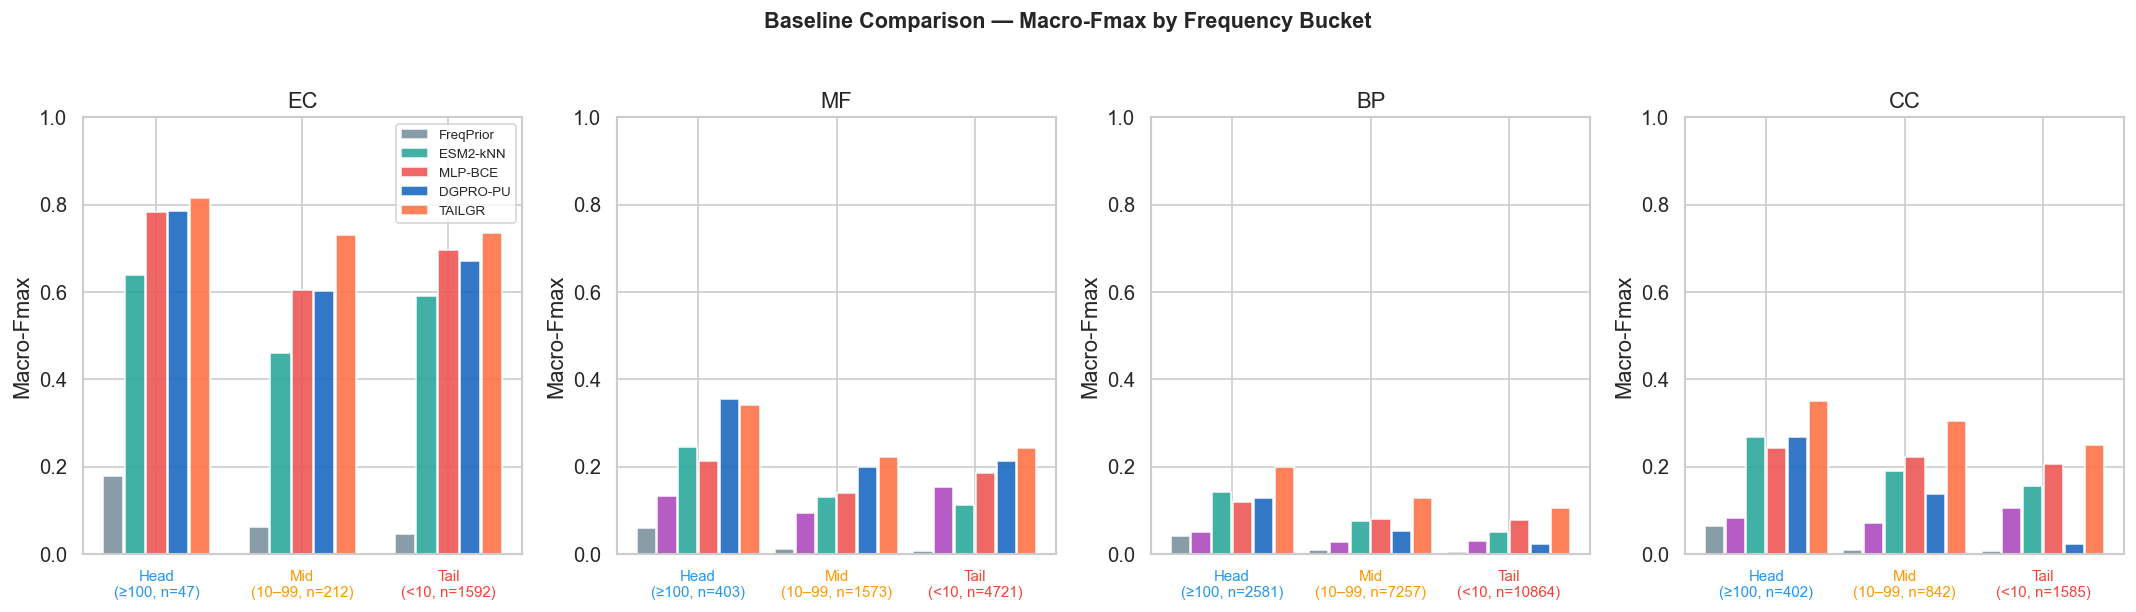

Saved eval_macro_fmax.pdf


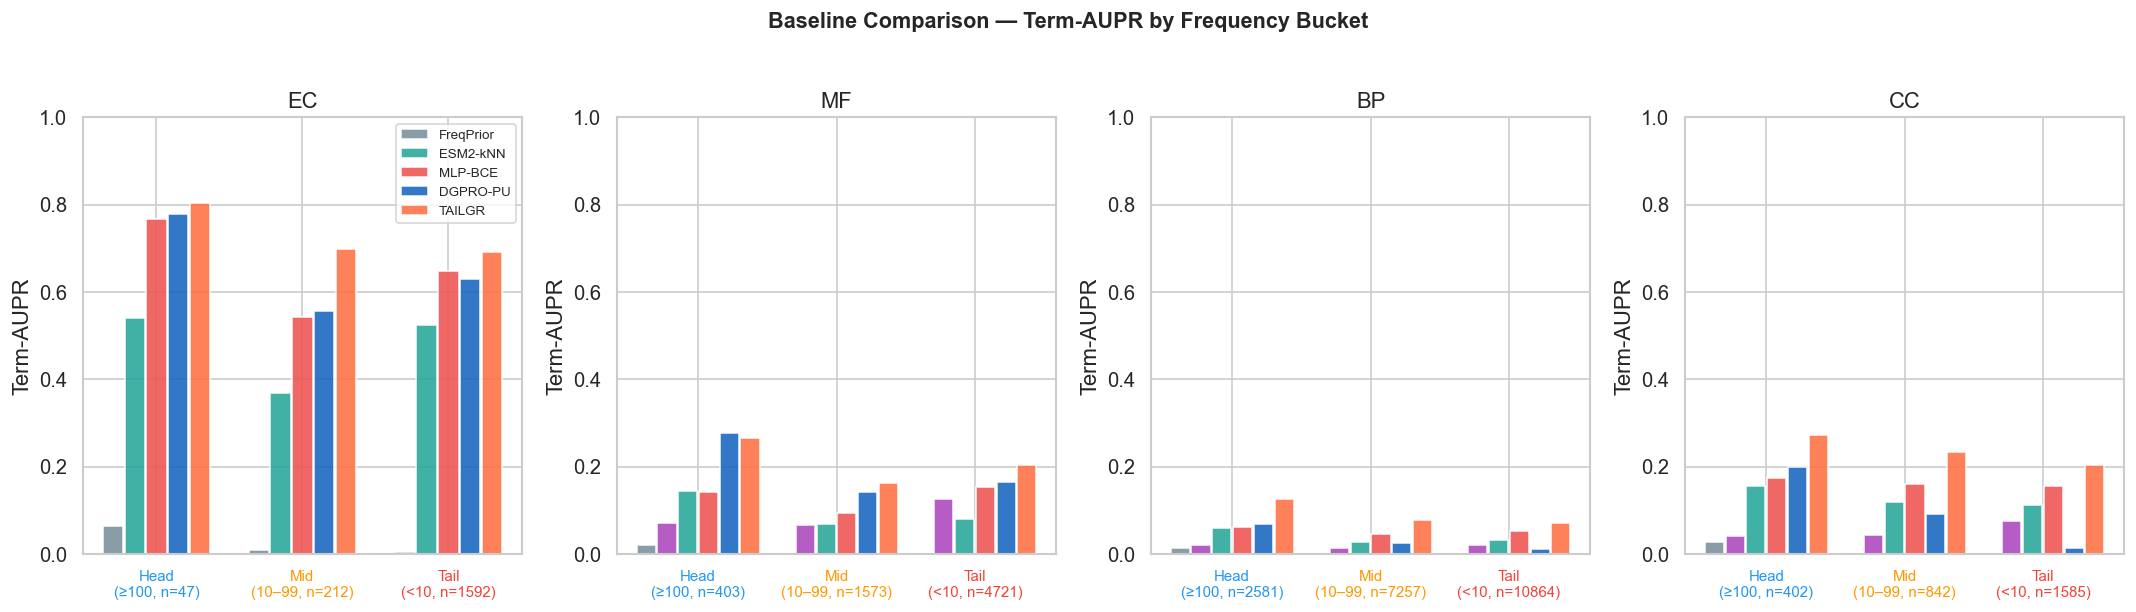

Saved eval_term_aupr.pdf


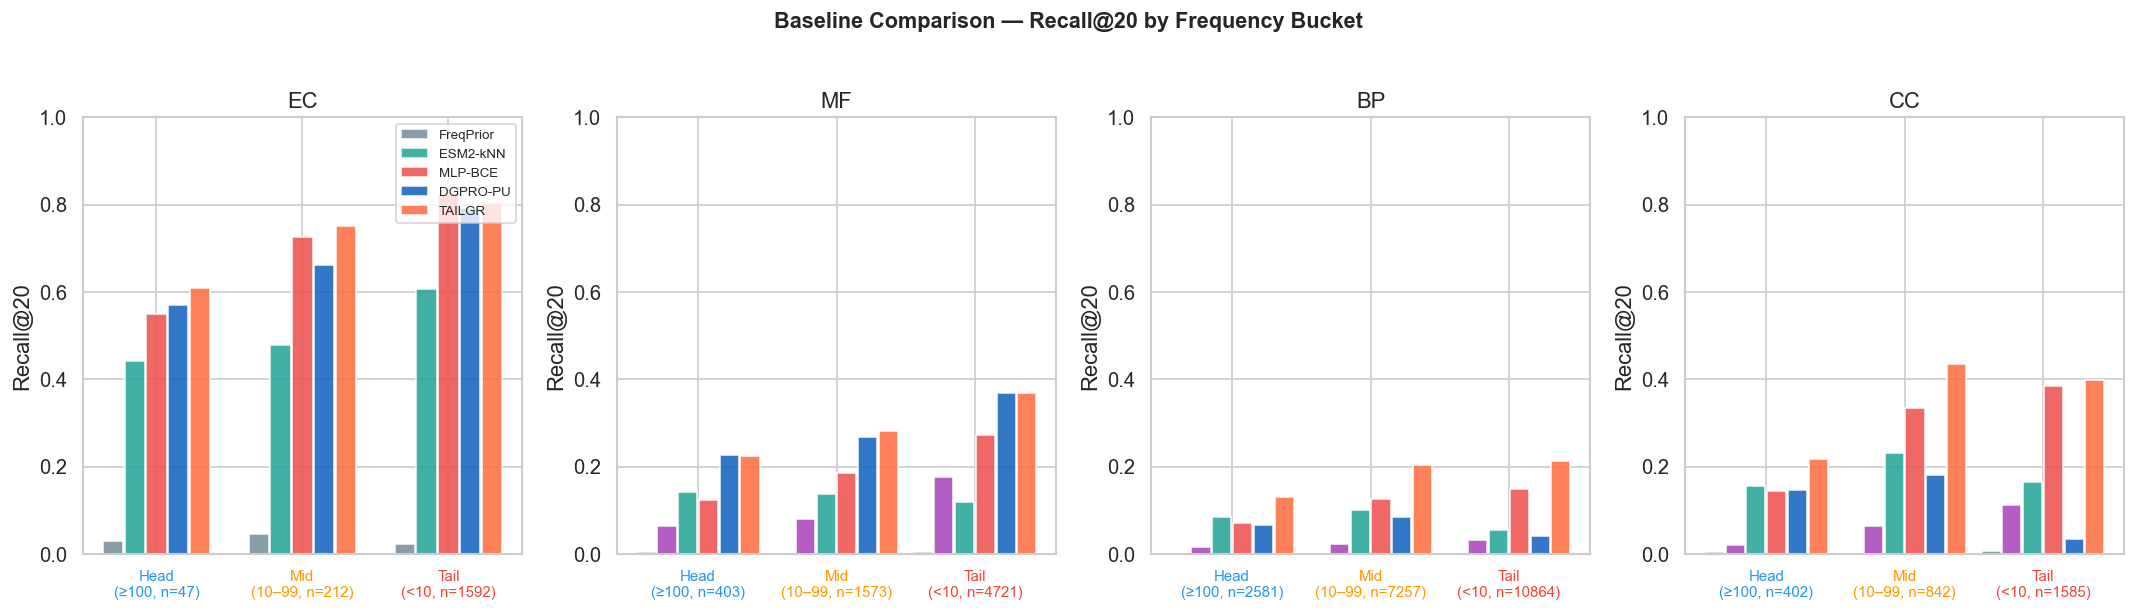

Saved eval_recall20.pdf


In [12]:
def plot_metric_bars(metric, save_name):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)

    for ax, ont in zip(axes, ONTS):
        d      = ONT_DATA[ont]
        models = [m for m in MODELS if m in RESULTS[ont]]
        x      = np.arange(len(BUCKETS))
        width  = 0.15
        offsets = np.linspace(-(len(models)-1)/2, (len(models)-1)/2, len(models)) * width

        for offset, model_name in zip(offsets, models):
            vals = [
                RESULTS[ont][model_name][b].get(metric, 0.0)
                for b in BUCKETS
            ]
            bars = ax.bar(x + offset, vals, width * 0.92,
                          label=model_name,
                          color=MODEL_COLORS[model_name],
                          alpha=0.88)

        ax.set_xticks(x)
        ax.set_xticklabels([
            f'Head\n(≥100, n={d["masks"]["head"].sum()})',
            f'Mid\n(10–99, n={d["masks"]["mid"].sum()})',
            f'Tail\n(<10, n={d["masks"]["tail"].sum()})',
        ], fontsize=9)
        ax.set_ylabel(metric)
        ax.set_title(ont.upper())
        ax.set_ylim(0, 1.0)
        if ont == ONTS[0]:
            ax.legend(fontsize=8, loc='upper right')

        # colour x-axis tick labels
        for label, color in zip(ax.get_xticklabels(), BCOLORS.values()):
            label.set_color(color)

    fig.suptitle(f'Baseline Comparison — {metric} by Frequency Bucket',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_name)
    plt.show()
    print(f'Saved {save_name}')

plot_metric_bars('Macro-Fmax',  'eval_macro_fmax.pdf')
plot_metric_bars('Term-AUPR',   'eval_term_aupr.pdf')
plot_metric_bars('Recall@20',   'eval_recall20.pdf')

## Head–Tail Performance Gap Analysis
How much does each model degrade from Head → Tail? Visualises the absolute drop and relative drop.

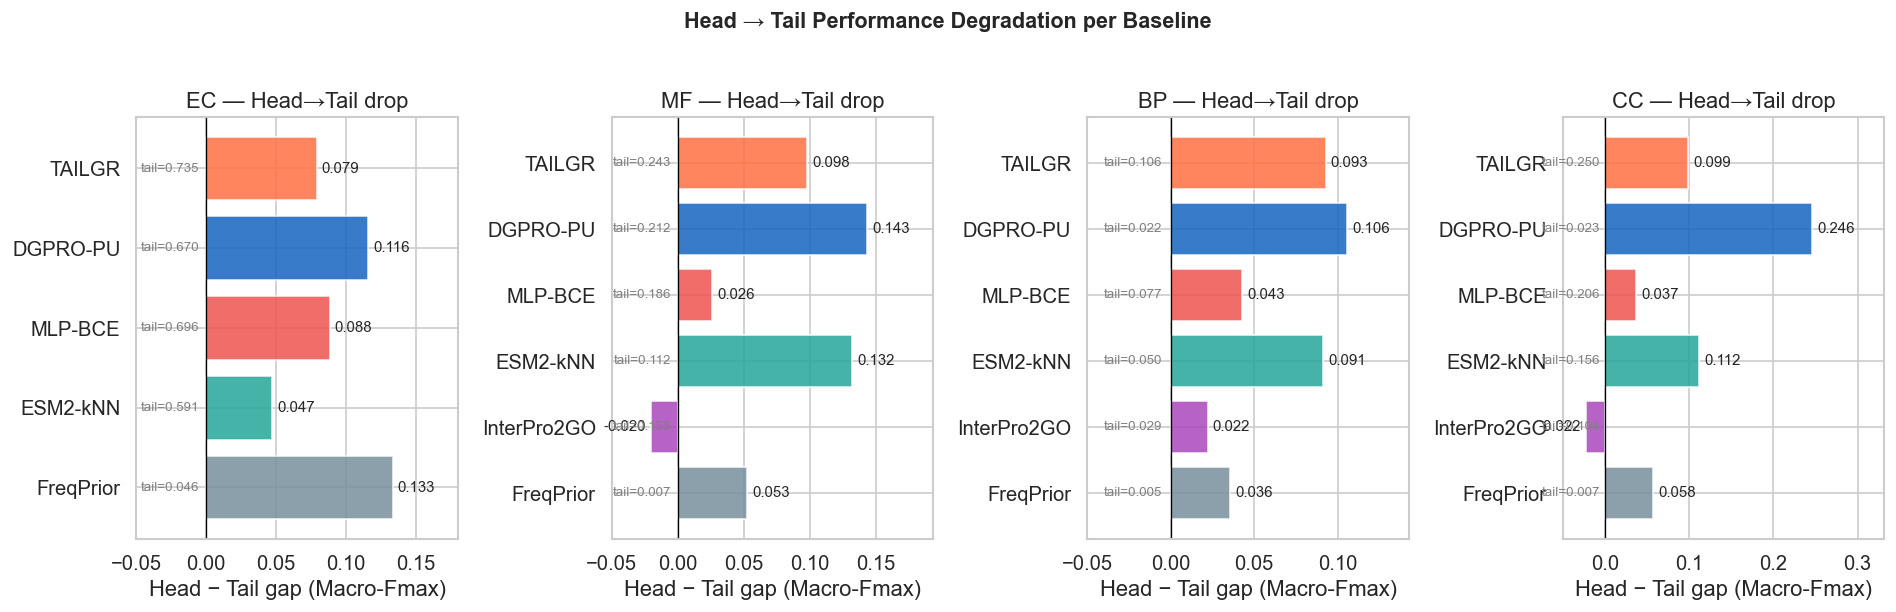

Saved eval_head_tail_gap.pdf


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

metric = 'Macro-Fmax'

for ax, ont in zip(axes, ONTS):
    models = [m for m in MODELS if m in RESULTS[ont]]
    head_scores = [RESULTS[ont][m]['head'][metric] for m in models]
    tail_scores = [RESULTS[ont][m]['tail'][metric] for m in models]
    gaps        = [h - t for h, t in zip(head_scores, tail_scores)]

    colors = [MODEL_COLORS[m] for m in models]
    bars = ax.barh(models, gaps, color=colors, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

    # overlay actual tail scores as text
    for i, (m, t) in enumerate(zip(models, tail_scores)):
        ax.text(-0.005, i, f'tail={t:.3f}', va='center', ha='right',
                fontsize=8, color='gray')

    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Head − Tail gap (Macro-Fmax)')
    ax.set_title(f'{ont.upper()} — Head→Tail drop')
    ax.set_xlim(-0.05, max(gaps) * 1.35 if gaps else 0.5)

fig.suptitle('Head → Tail Performance Degradation per Baseline',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_head_tail_gap.pdf')
plt.show()
print('Saved eval_head_tail_gap.pdf')

## Score Calibration: Prediction Score Distribution by Bucket
Histogram of predicted scores for Head / Mid / Tail true positives vs. negatives — shows whether models are well-calibrated and where they fail on tail terms.

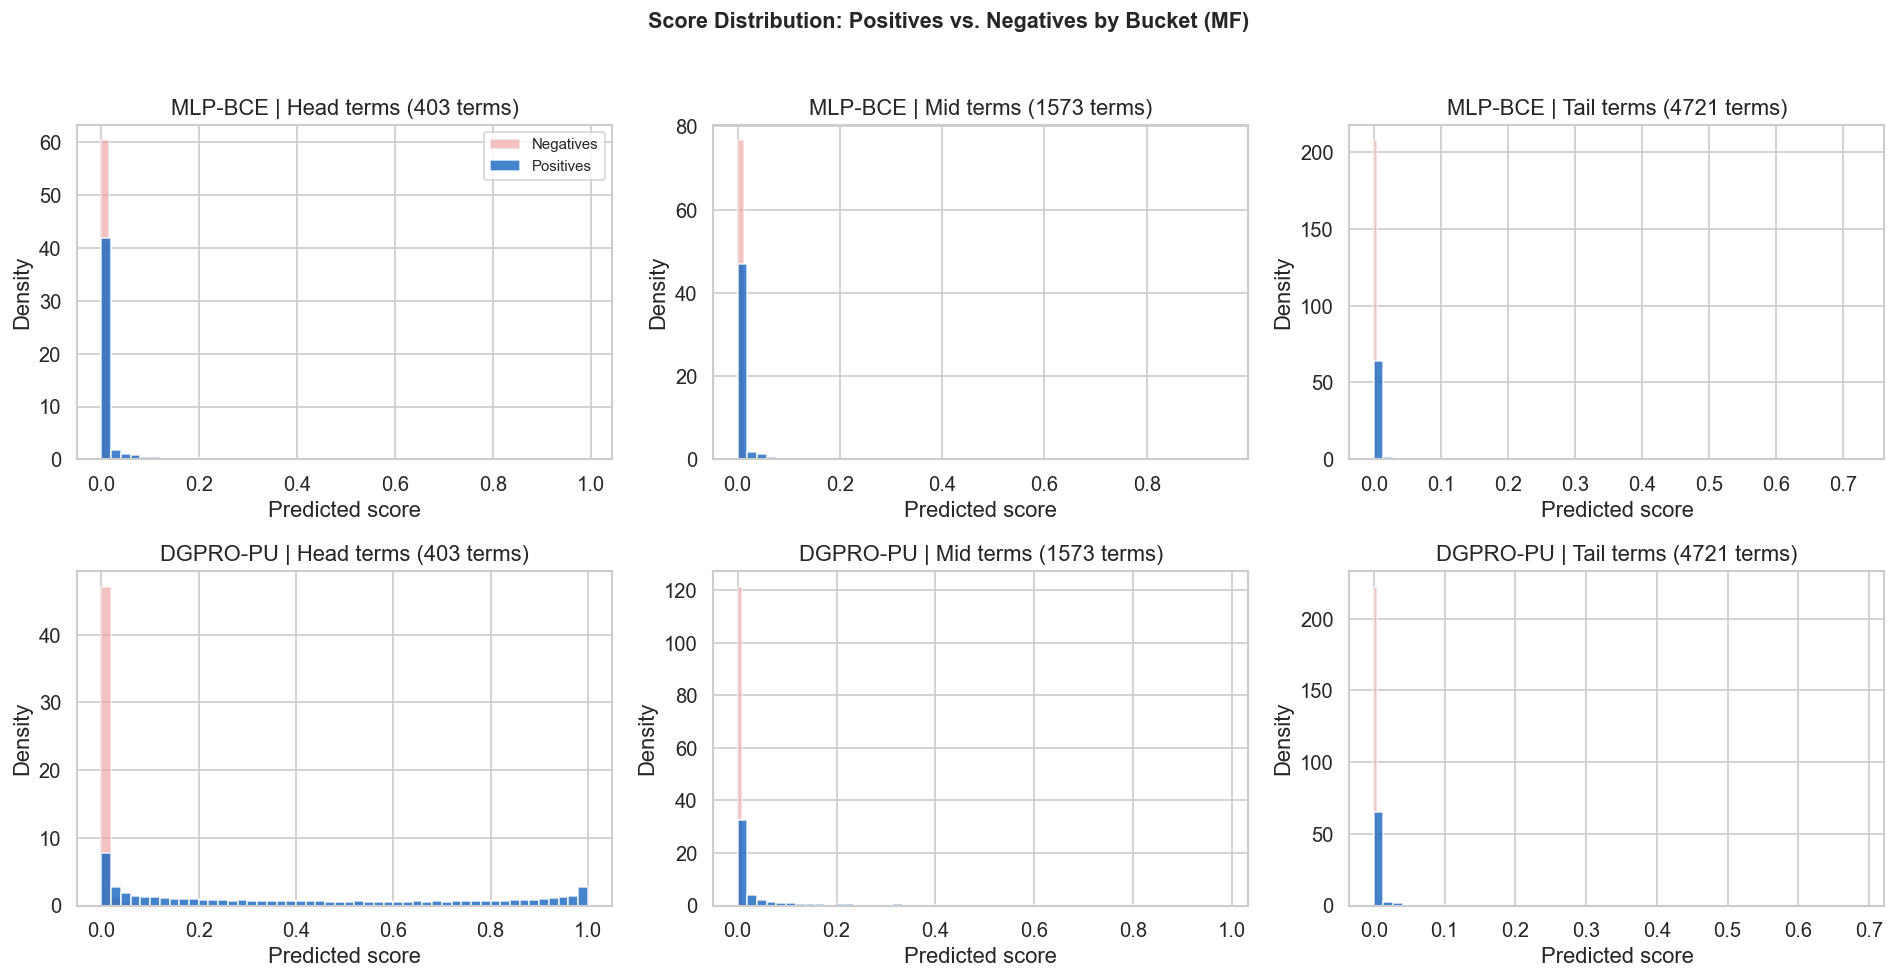

Saved eval_score_calibration.pdf


In [14]:
def get_preds_for_model(ont, model_name):
    d = ONT_DATA[ont]
    if model_name == 'FreqPrior':
        freq = d['freq'].astype(float)
        return np.tile(freq / (freq.max()+1e-10), (len(d['Xte']), 1))
    elif model_name == 'InterPro2GO':
        K, t2i, te = d['K'], d['term2idx'], d['test_df']
        p = np.zeros((len(te), K), dtype=np.float32)
        for i, i2g in enumerate(te['interpro2go']):
            for g in i2g:
                if g in t2i: p[i, t2i[g]] = 1.0
        no_hit = p.sum(1) == 0
        p[no_hit] = d['freq'].astype(float) / (d['freq'].max()+1e-10)
        return p
    elif model_name == 'ESM2-kNN':
        K = d['K']
        Xtr = F.normalize(d['Xtr'], dim=1).to(DEVICE)
        Ytr = d['Ytr'].to(DEVICE)
        Xte = F.normalize(d['Xte'], dim=1)
        p   = np.zeros((len(Xte), K), dtype=np.float32)
        for i in range(0, len(Xte), 256):
            xb  = Xte[i:i+256].to(DEVICE)
            idx = (xb @ Xtr.T).topk(KNN_K, dim=1).indices
            p[i:i+256] = Ytr[idx].mean(1).cpu().numpy()
        return p
    elif model_name == 'MLP-BCE':
        ckpt  = f'baseline_mlp_bce_{ont}.pt'
        model = MLP_BCE(d['K']).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        model.eval()
        with torch.no_grad():
            return torch.sigmoid(torch.cat(
                [model(d['Xte'][i:i+256].to(DEVICE)) for i in range(0,len(d['Xte']),256)]
            )).cpu().numpy()
    elif model_name == 'DGPRO-PU':
        ckpt  = f'baseline_dgpro_{ont}.pt'
        model = DGPRO(d['K']).to(DEVICE)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        model.eval()
        with torch.no_grad():
            return torch.sigmoid(torch.cat(
                [model(d['Xte'][i:i+256].to(DEVICE)) for i in range(0,len(d['Xte']),256)]
            )).cpu().numpy()

ont = 'mf'
d   = ONT_DATA[ont]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_models = ['MLP-BCE', 'DGPRO-PU']

for row, model_name in enumerate(plot_models):
    preds  = get_preds_for_model(ont, model_name)
    labels = d['Yte'].numpy()

    for col, bucket in enumerate(BUCKETS):
        ax   = axes[row, col]
        mask = d['masks'][bucket]

        pos_scores = preds[:, mask][labels[:, mask] == 1].ravel()
        neg_scores = preds[:, mask][labels[:, mask] == 0].ravel()

        rng = np.random.default_rng(0)
        neg_scores = rng.choice(neg_scores, size=min(len(neg_scores), 50000), replace=False)

        ax.hist(neg_scores, bins=50, density=True, alpha=0.6,
                color='#EF9A9A', label='Negatives')
        ax.hist(pos_scores, bins=50, density=True, alpha=0.8,
                color='#1565C0', label='Positives')
        ax.set_xlabel('Predicted score')
        ax.set_ylabel('Density')
        ax.set_title(f'{model_name} | {bucket.capitalize()} terms ({mask.sum()} terms)')
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

fig.suptitle(f'Score Distribution: Positives vs. Negatives by Bucket ({ont.upper()})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_score_calibration.pdf')
plt.show()
print('Saved eval_score_calibration.pdf')

## Save Full Results to CSV

In [15]:
rows = []
for ont in ONTS:
    for model_name in MODELS:
        if model_name not in RESULTS[ont]:
            continue
        for bucket in BUCKETS:
            for metric, val in RESULTS[ont][model_name][bucket].items():
                rows.append({
                    'ont':    ont.upper(),
                    'model':  model_name,
                    'bucket': bucket,
                    'metric': metric,
                    'value':  round(val, 6),
                })

df_all = pd.DataFrame(rows)
df_all.to_csv('baseline_results.csv', index=False)
print('Saved baseline_results.csv')

pivot = df_all[df_all['metric'] == 'Macro-Fmax'].pivot_table(
    index=['ont', 'model'], columns='bucket', values='value'
).round(4)
display(pivot)

Saved baseline_results.csv


bucket             head     mid    tail
ont model                              
BP  DGPRO-PU     0.1279  0.0530  0.0222
    ESM2-kNN     0.1416  0.0748  0.0505
    FreqPrior    0.0403  0.0081  0.0047
    InterPro2GO  0.0507  0.0265  0.0286
    MLP-BCE      0.1198  0.0801  0.0770
    TAILGR       0.1984  0.1284  0.1056
CC  DGPRO-PU     0.2690  0.1369  0.0230
    ESM2-kNN     0.2678  0.1895  0.1557
    FreqPrior    0.0643  0.0100  0.0067
    InterPro2GO  0.0821  0.0711  0.1045
    MLP-BCE      0.2431  0.2231  0.2061
    TAILGR       0.3493  0.3040  0.2504
EC  DGPRO-PU     0.7863  0.6026  0.6703
    ESM2-kNN     0.6384  0.4602  0.5913
    FreqPrior    0.1791  0.0619  0.0457
    MLP-BCE      0.7838  0.6051  0.6957
    TAILGR       0.8143  0.7304  0.7354
MF  DGPRO-PU     0.3553  0.1998  0.2119
    ESM2-kNN     0.2444  0.1310  0.1124
    FreqPrior    0.0598  0.0111  0.0072
    InterPro2GO  0.1333  0.0948  0.1535
    MLP-BCE      0.2123  0.1398  0.1864
    TAILGR       0.3412  0.2217  0.2432